In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import RandomizedSearchCV

import pickle

In [2]:
gold_dataset = pd.read_csv("Gold vs USDINR.csv")

### Data Analysis

In [3]:
gold_dataset.head()

,Date,USD_INR,Goldrate
0,2024-01-01,83.240601,"₹5,066.31"
1,2024-01-08,83.076103,"₹4,966.31"
2,2024-01-15,83.160599,"₹5,015.33"
3,2024-01-22,83.146103,"₹4,950.84"
4,2024-01-29,82.927597,"₹4,976.77"


In [4]:
gold_dataset['Goldrate'] = gold_dataset['Goldrate'].replace('₹', '', regex=True).replace(',', '', regex=True).astype(float)

In [5]:
gold_dataset.head()

,Date,USD_INR,Goldrate
0,2024-01-01,83.240601,5066.31
1,2024-01-08,83.076103,4966.31
2,2024-01-15,83.160599,5015.33
3,2024-01-22,83.146103,4950.84
4,2024-01-29,82.927597,4976.77


### EDA

1. Handle missing valuse
2. handle imbalanced data
3. Handle outliers
4. Encode categorical feature
5. Normalization vs Standardisation

<Axes: ylabel='USD_INR'>

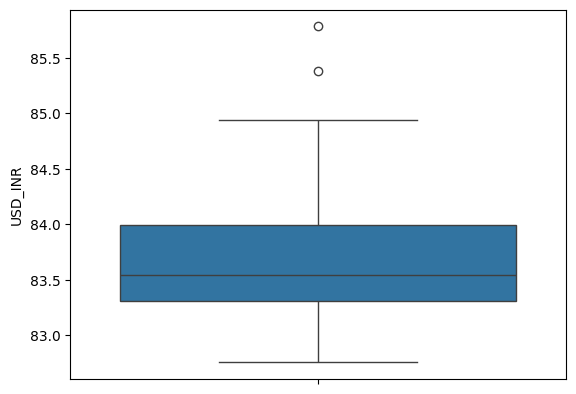

In [6]:
sns.boxplot(gold_dataset['USD_INR'])

In [7]:
Q1 = gold_dataset['USD_INR'].quantile(0.25)  # 25th percentile
Q3 = gold_dataset['USD_INR'].quantile(0.75)  # 75th percentile
IQR = Q3 - Q1  # Interquartile range

# Define lower and upper bound
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

upper_bound

np.float64(85.01979063999997)

In [8]:
print("Maximum: ", max(gold_dataset['USD_INR']))
print("Minimum: ", min(gold_dataset['USD_INR']))

Maximum:  85.78659821
Minimum:  82.75229645


<Axes: xlabel='USD_INR', ylabel='Goldrate'>

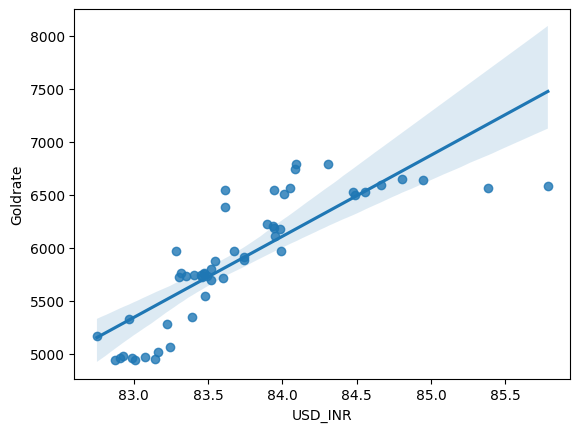

In [9]:
sns.regplot(x = 'USD_INR', y='Goldrate', data=gold_dataset)

### Model Training

In [10]:
x = gold_dataset['USD_INR']
y = gold_dataset['Goldrate']

In [11]:
type(x)

pandas.core.series.Series

In [12]:
x

0     83.240601
1     83.076103
2     83.160599
3     83.146103
4     82.927597
5     82.985298
6     83.009598
7     82.872299
8     82.910400
9     82.752296
10    82.965599
11    83.226601
12    83.392998
13    83.477798
14    83.349297
15    83.544998
16    83.301804
17    83.406303
18    83.459396
19    83.470100
20    83.286400
21    83.320900
22    83.473099
23    83.522102
24    83.601601
25    83.450897
26    83.493401
27    83.518501
28    83.674301
29    83.744400
30    83.743896
31    83.988998
32    83.948303
33    83.940598
34    83.895103
35    83.983597
36    83.934799
37    83.614700
38    83.617104
39    84.009399
40    83.945999
41    84.053802
42    84.081802
43    84.091499
44    84.306396
45    84.473801
46    84.488297
47    84.556999
48    84.666000
49    84.802002
50    84.945000
51    85.386002
52    85.786598
Name: USD_INR, dtype: float64

In [13]:
x = gold_dataset[['USD_INR']]
y = gold_dataset[['Goldrate']]

In [14]:
type(x)

pandas.core.frame.DataFrame

In [15]:
x

,USD_INR
0,83.240601
1,83.076103
2,83.160599
3,83.146103
4,82.927597
5,82.985298
6,83.009598
7,82.872299
8,82.910400
9,82.752296


In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=42)

In [17]:
x_train

,USD_INR
17,83.406303
50,84.945000
3,83.146103
32,83.948303
13,83.477798
8,82.910400
26,83.493401
6,83.009598
34,83.895103
4,82.927597


In [18]:
x_train.shape, x_test.shape

((47, 1), (6, 1))

In [19]:
scalar = StandardScaler()

In [20]:
x_train_scaled = scalar.fit_transform(x_train)

In [21]:
x_train_scaled

array([[-0.4753469 ],
       [ 1.91603897],
       [-0.87974106],
       [ 0.36700952],
       [-0.36423189],
       [-1.24606136],
       [-0.33998365],
       [-1.09189238],
       [ 0.28432837],
       [-1.21933493],
       [-0.15146399],
       [-0.17182302],
       [ 0.92354506],
       [ 0.35503362],
       [ 1.69379708],
       [-0.25979254],
       [-1.49178076],
       [-0.63775672],
       [ 0.04932799],
       [ 0.34602205],
       [-0.40604082],
       [-0.7546344 ],
       [-0.7328762 ],
       [ 1.20624748],
       [-0.30097304],
       [ 0.43025651],
       [ 0.461963  ],
       [ 0.05011057],
       [ 1.18371856],
       [-0.98853205],
       [-0.60807784],
       [-0.85721215],
       [ 0.36342862],
       [ 0.42186152],
       [-0.29537637],
       [ 1.48242836],
       [-1.16027359],
       [-0.371536  ],
       [-0.39283176],
       [ 3.22402082],
       [-0.66169667],
       [-1.30527686],
       [ 0.57448905],
       [-0.56394486],
       [-0.05883454],
       [ 2

In [22]:
x_test_scaled = scalar.transform(x_test)

In [23]:
x_test_scaled

array([[-0.37619593],
       [ 0.53097266],
       [ 1.31302272],
       [-0.49602609],
       [ 0.58955971],
       [-1.12965796]])

In [24]:
regressor = LinearRegression()

In [25]:
regressor.fit(x_train_scaled, y_train)

LinearRegression()

In [26]:
regressor.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [27]:
# y = mx+b
m = regressor.coef_[0][0]
b = regressor.intercept_[0]

In [28]:
m , b

(np.float64(469.2075576153299), np.float64(5878.573404255313))

In [29]:
x_train_predict = regressor.predict(x_train_scaled)

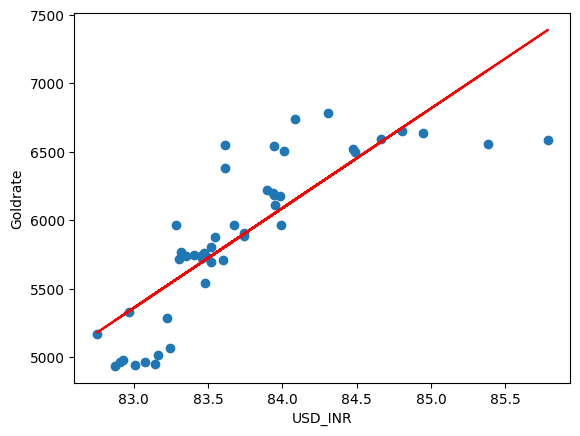

In [30]:
plt.scatter(x_train, y_train)
plt.plot(x_train, x_train_predict, color='r')
plt.xlabel('USD_INR')
plt.ylabel('Goldrate')

plt.show()

In [31]:
x_test_predicted = regressor.predict(x_test_scaled)

In [32]:
x_test_predicted

array([[5702.05943009],
       [6127.70978702],
       [6494.65358787],
       [5645.83421639],
       [6155.1992781 ],
       [5348.52935023]])

In [33]:
y_test

,Goldrate
19,5754.39
41,6563.33
47,6524.06
12,5341.21
43,6795.35
5,4953.90


### Hyperparameter optimization

In [34]:
param_space = {'copy_X': [True, False],
               'fit_intercept': [True, False],
               'n_jobs': [1, 5, 10, 15, None],
               'positive': [True, False]}

In [35]:
search = RandomizedSearchCV(regressor, param_space, n_iter=50, cv=5)

In [36]:
search.fit(x_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 40 is smaller than n_iter=50. Running 40 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=LinearRegression(), n_iter=50,
                   param_distributions={'copy_X': [True, False],
                                        'fit_intercept': [True, False],
                                        'n_jobs': [1, 5, 10, 15, None],
                                        'positive': [True, False]})

In [37]:
search.best_params_

{'positive': True, 'n_jobs': 1, 'fit_intercept': True, 'copy_X': True}

In [38]:
tuned_model = LinearRegression(positive= True, n_jobs= 1, fit_intercept= True, copy_X= True)

In [39]:
tuned_model.fit(x_train_scaled, y_train)

LinearRegression(n_jobs=1, positive=True)

In [40]:
tuned_m = tuned_model.coef_[0][0]
tuned_b = tuned_model.intercept_[0]

tuned_m, tuned_b

(np.float64(469.20755761532996), np.float64(5878.573404255313))

### MLOPS

In [41]:
pickle.dump(tuned_model, open('regressor.pkl', 'wb'))

In [42]:
regressor_reloaded = pickle.load(open('regressor.pkl', 'rb'))

In [43]:
regressor_reloaded.coef_

array([[469.20755762]])

In [44]:
pickle.dump(scalar, open('scalar.pkl', 'wb'))

In [45]:
scalar_reloaded = pickle.load(open('scalar.pkl', 'rb'))

In [46]:
def calculate_gold_rate(usd_inr):
    scaled_input = scalar_reloaded.transform(np.array(usd_inr).reshape(1, -1))
    prediction = regressor_reloaded.predict(scaled_input)[0][0].round(2)
    return prediction

In [47]:
calculate_gold_rate(82)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


np.float64(4630.02)

In [48]:
import gradio as gr

In [49]:
demo = gr.Interface(
    fn=calculate_gold_rate,
    inputs=['number'],
    outputs=['number'],
    title='Gold rate prediction based on USD'
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
